# Credit Card Fraud Detection

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
csv_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(csv_path)

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

## 1. Class imbalance analysis

The target variable is heavily imbalanced. This is critical for understanding model evaluation metrics.

Class Distribution:
  Legitimate transactions: 284,315 (99.83%)
  Fraudulent transactions: 492 (0.17%)

Imbalance ratio: 577.9:1 (legitimate:fraud)


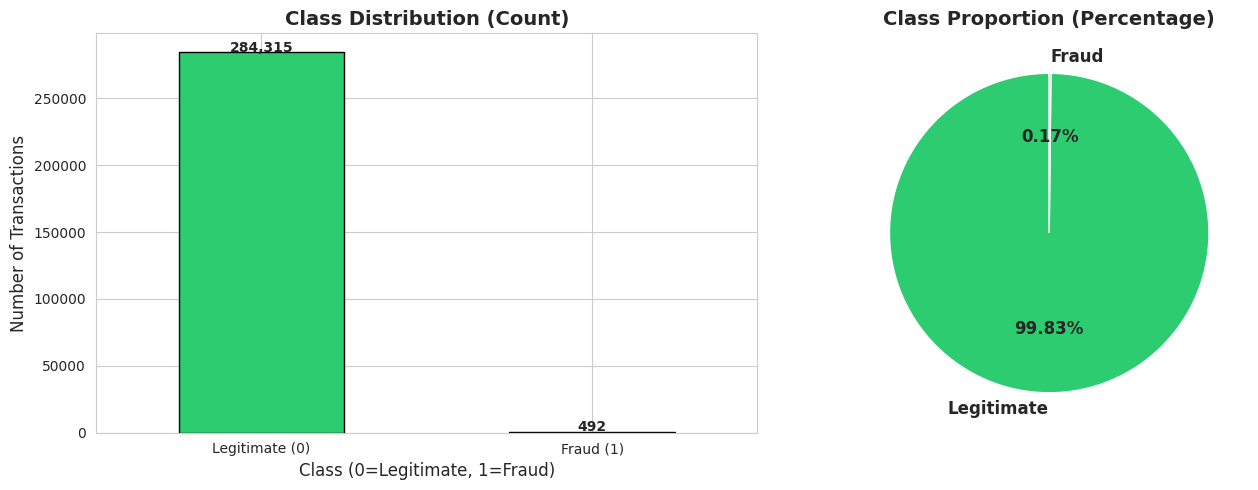


✓ Visualization saved to: reports/figures/01_class_imbalance.png


In [3]:
# Class distribution
class_counts = df['Class'].value_counts()
fraud_ratio = class_counts[1] / len(df) * 100

print(f"Class Distribution:")
print(f"  Legitimate transactions: {class_counts[0]:,} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"  Fraudulent transactions: {class_counts[1]:,} ({fraud_ratio:.2f}%)")
print(f"\nImbalance ratio: {class_counts[0] / class_counts[1]:.1f}:1 (legitimate:fraud)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']  # Green for legitimate, Red for fraud
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)', fontsize=12)
axes[0].set_ylabel('Number of Transactions', fontsize=12)
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/01_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: reports/figures/01_class_imbalance.png")

### Why naive accuracy is useless Here

With only **0.17% fraudulent transactions**, a model that predicts "all transactions are legitimate" would achieve **99.83% accuracy**, yet it would be completely useless for fraud detection since it would catch **zero fraud cases**.

**Key insight:** With this imbalance, we must use metrics that care about minority class performance:
- **Precision & Recall:** Focus on fraud detection performance
- **F1 Score:** Harmonic mean of precision and recall
- **AUC-ROC:** Threshold-independent metric
- **Confusion Matrix:** See false positives and false negatives explicitly

**Business context:** 
- Missing a fraud (False Negative = missed fraud) costs money and trust
- False alarms (False Positive = wrongly blocking) frustrate customers
- The optimal metric depends on business tolerance for these trade-offs

## 2. Fraud by time: when do fraudsters strike?

Understanding temporal patterns helps identify when fraud is most likely. This is a business insight because fraudsters may have specific patterns (e.g., more at night, on weekends).

Fraud Rate by Hour of Day:
 Hour  fraud_rate
    0    0.077973
    1    0.236967
    2    1.712740
    3    0.486827
    4    1.041195
    5    0.367893
    6    0.219459
    7    0.317548
    8    0.087583
    9    0.101023
   10    0.048199
   11    0.314428
   12    0.110246
   13    0.110641
   14    0.138805
   15    0.157949
   16    0.133714
   17    0.179389
   18    0.193673
   19    0.121414
   20    0.107424
   21    0.090380
   22    0.058286
   23    0.191991

Peak fraud hour: Hour 2 (1.713% fraud rate)
Lowest fraud hour: Hour 10 (0.048% fraud rate)


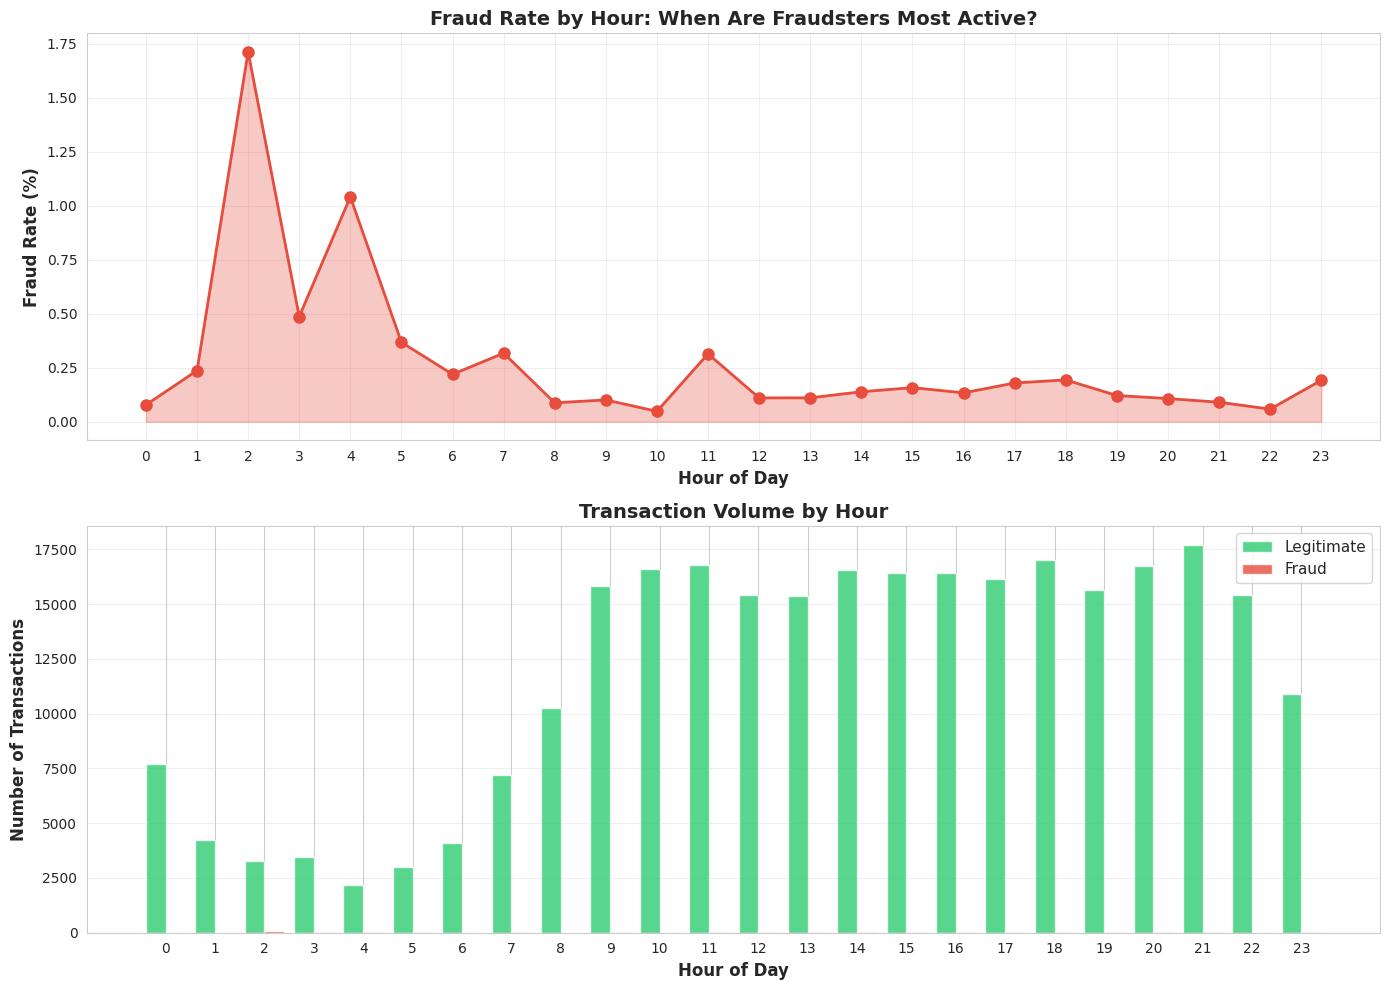


✓ Visualization saved to: reports/figures/02_fraud_by_time.png


In [4]:
# Create time bins (seconds to hours and time of day categories)
# Time is in seconds since the dataset starts, so we can bin into hours
hours_in_day = 24
max_time = df['Time'].max()
seconds_per_hour = 3600

# Convert Time to hours
df['Hour'] = (df['Time'] / seconds_per_hour) % hours_in_day

# Calculate fraud rate by hour
fraud_by_hour = df.groupby(df['Hour'].astype(int))['Class'].agg(['sum', 'count'])
fraud_by_hour['fraud_rate'] = (fraud_by_hour['sum'] / fraud_by_hour['count']) * 100
fraud_by_hour = fraud_by_hour.reset_index()

print("Fraud Rate by Hour of Day:")
print(fraud_by_hour[['Hour', 'fraud_rate']].to_string(index=False))

# Find peak fraud hours
peak_hour = fraud_by_hour.loc[fraud_by_hour['fraud_rate'].idxmax()]
low_hour = fraud_by_hour.loc[fraud_by_hour['fraud_rate'].idxmin()]

print(f"\nPeak fraud hour: Hour {peak_hour['Hour']:.0f} ({peak_hour['fraud_rate']:.3f}% fraud rate)")
print(f"Lowest fraud hour: Hour {low_hour['Hour']:.0f} ({low_hour['fraud_rate']:.3f}% fraud rate)")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Line plot of fraud rate by hour
axes[0].plot(fraud_by_hour['Hour'], fraud_by_hour['fraud_rate'], marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0].fill_between(fraud_by_hour['Hour'], fraud_by_hour['fraud_rate'], alpha=0.3, color='#e74c3c')
axes[0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Fraud Rate by Hour: When Are Fraudsters Most Active?', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))

# Bar plot: transaction count by hour
fraud_counts = df[df['Class'] == 1].groupby(df[df['Class'] == 1]['Hour'].astype(int)).size()
legit_counts = df[df['Class'] == 0].groupby(df[df['Class'] == 0]['Hour'].astype(int)).size()

hours = range(24)
axes[1].bar([h - 0.2 for h in hours], legit_counts.reindex(hours, fill_value=0), width=0.4, label='Legitimate', color='#2ecc71', alpha=0.8)
axes[1].bar([h + 0.2 for h in hours], fraud_counts.reindex(hours, fill_value=0), width=0.4, label='Fraud', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[1].set_title('Transaction Volume by Hour', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/02_fraud_by_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: reports/figures/02_fraud_by_time.png")

## 3. Fraud by amount: do fraudsters make small test transactions?

Are fraudsters making small "test" transactions to check if a card works, or are they going for big scores? This business question reveals fraud strategy.

Transaction Amount Statistics:

Legitimate transactions:
  Count: 284,315
  Mean: $88.29
  Median: $22.00
  Min: $0.00
  Max: $25691.16
  Std: $250.11

Fraudulent transactions:
  Count: 492
  Mean: $122.21
  Median: $9.25
  Min: $0.00
  Max: $2125.87
  Std: $256.68

Small fraud transactions (< $5): 221 (44.9%)


/tmp/ipykernel_2005/3074774967.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)


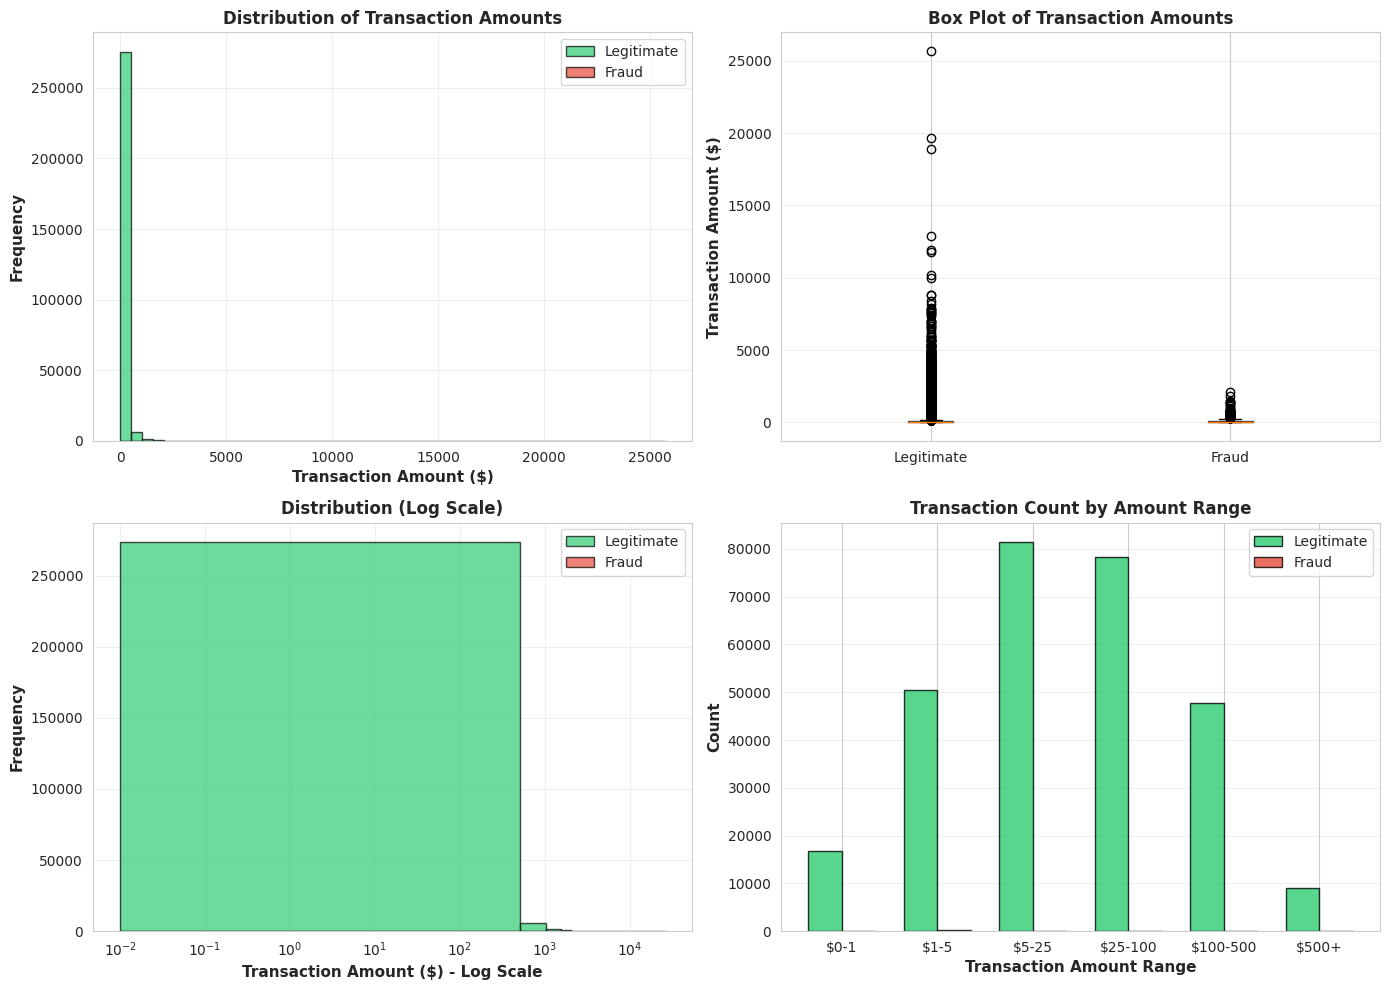


✓ Visualization saved to: reports/figures/03_fraud_by_amount.png


In [5]:
# Separate legitimate and fraudulent transactions
legitimate = df[df['Class'] == 0]['Amount']
fraudulent = df[df['Class'] == 1]['Amount']

# Summary statistics
print("Transaction Amount Statistics:")
print(f"\nLegitimate transactions:")
print(f"  Count: {len(legitimate):,}")
print(f"  Mean: ${legitimate.mean():.2f}")
print(f"  Median: ${legitimate.median():.2f}")
print(f"  Min: ${legitimate.min():.2f}")
print(f"  Max: ${legitimate.max():.2f}")
print(f"  Std: ${legitimate.std():.2f}")

print(f"\nFraudulent transactions:")
print(f"  Count: {len(fraudulent):,}")
print(f"  Mean: ${fraudulent.mean():.2f}")
print(f"  Median: ${fraudulent.median():.2f}")
print(f"  Min: ${fraudulent.min():.2f}")
print(f"  Max: ${fraudulent.max():.2f}")
print(f"  Std: ${fraudulent.std():.2f}")

# Test transactions (< $5)
small_fraud = (fraudulent < 5).sum()
print(f"\nSmall fraud transactions (< $5): {small_fraud} ({small_fraud/len(fraudulent)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(legitimate, bins=50, alpha=0.7, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[0, 0].hist(fraudulent, bins=50, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black')
axes[0, 0].set_xlabel('Transaction Amount ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution of Transaction Amounts', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
data_to_plot = [legitimate, fraudulent]
bp = axes[0, 1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_ylabel('Transaction Amount ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Box Plot of Transaction Amounts', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Log-scale histogram (to see patterns better)
axes[1, 0].hist(legitimate[legitimate > 0], bins=50, alpha=0.7, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[1, 0].hist(fraudulent[fraudulent > 0], bins=50, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Transaction Amount ($) - Log Scale', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Amount ranges
amount_ranges = [(0, 1), (1, 5), (5, 25), (25, 100), (100, 500), (500, 2500)]
range_labels = ['$0-1', '$1-5', '$5-25', '$25-100', '$100-500', '$500+']
legit_counts = []
fraud_counts = []

for low, high in amount_ranges:
    legit_counts.append(((legitimate >= low) & (legitimate < high)).sum())
    fraud_counts.append(((fraudulent >= low) & (fraudulent < high)).sum())

x = np.arange(len(range_labels))
width = 0.35

axes[1, 1].bar(x - width/2, legit_counts, width, label='Legitimate', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, fraud_counts, width, label='Fraud', color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Transaction Amount Range', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Transaction Count by Amount Range', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(range_labels)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/03_fraud_by_amount.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: reports/figures/03_fraud_by_amount.png")

## 4. Feature correlation: which features predict fraud?

The dataset has 28 PCA-transformed features (V1-V28). Let's see which features have the strongest correlation with fraud.

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


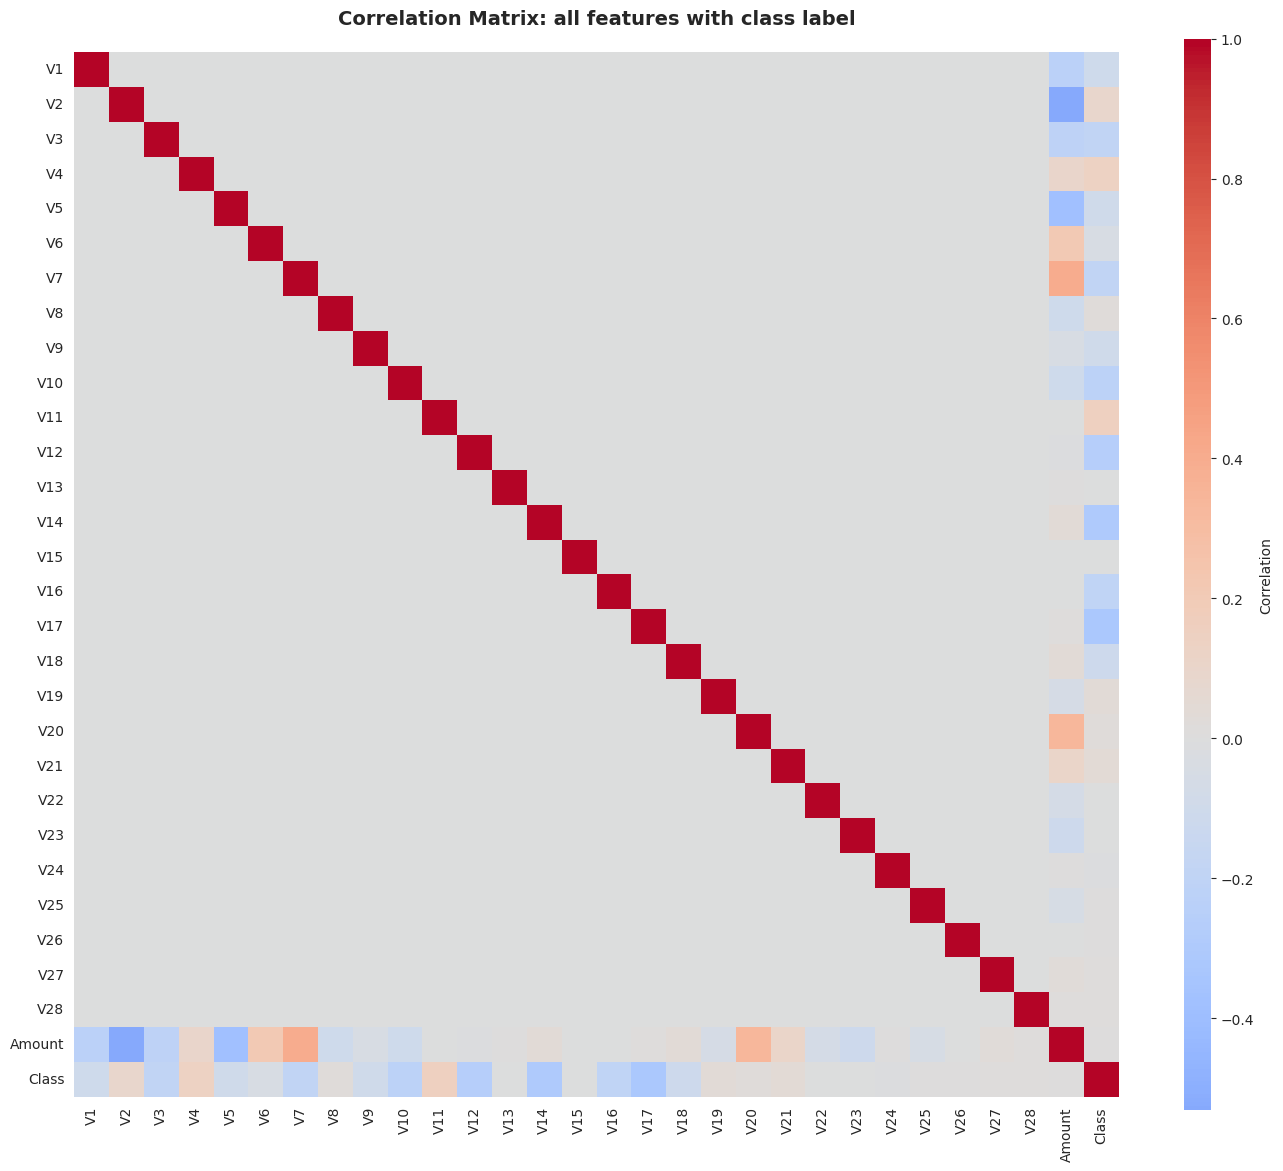

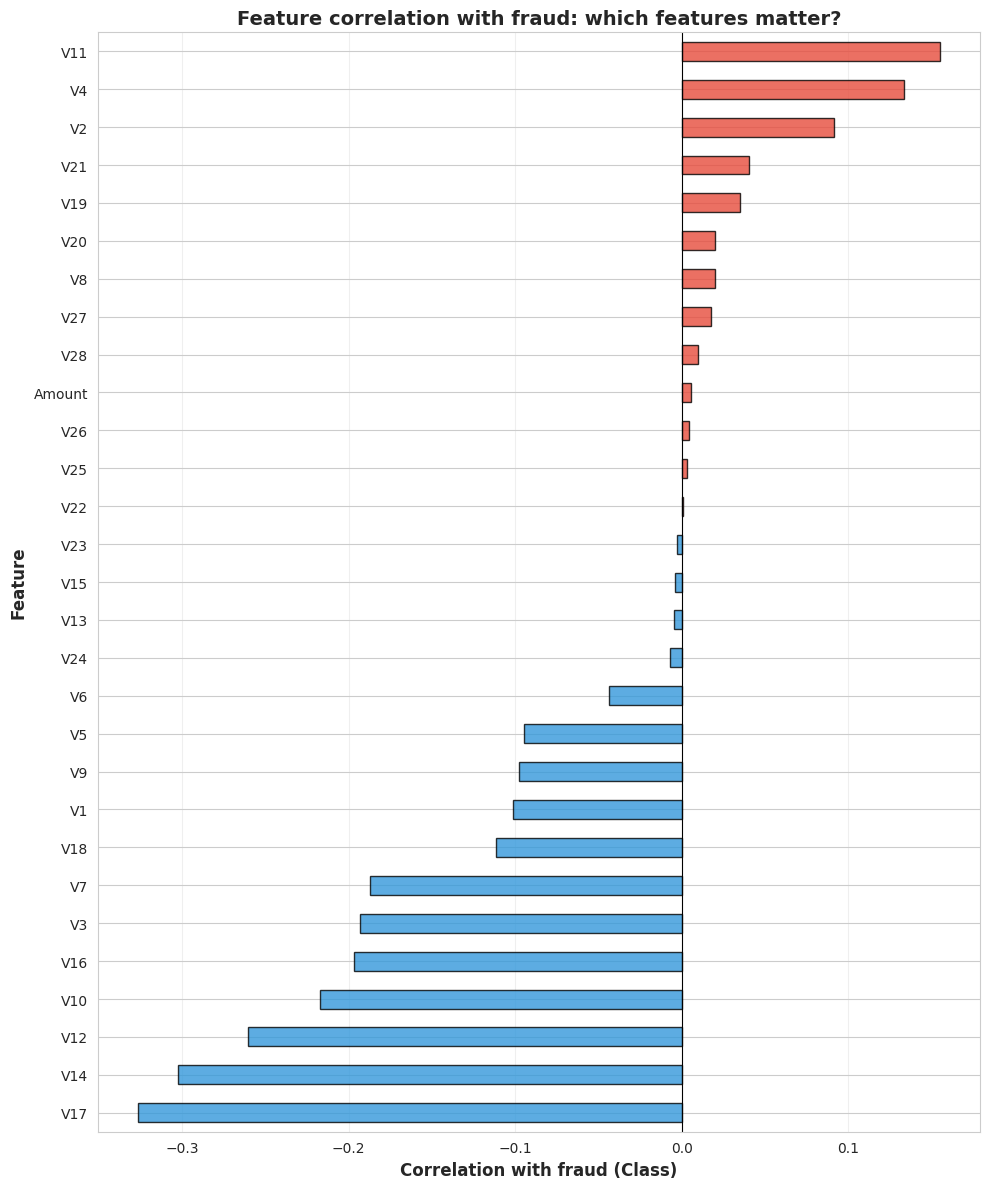


✓ Visualizations saved to:
  - reports/figures/04_correlation_heatmap_full.png
  - reports/figures/04_correlation_with_class.png


In [11]:
# Calculate correlations with target
v_features = [f'V{i}' for i in range(1, 29)]
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').abs().sort_values(ascending=False)

print("Top 10 features correlated with fraud:")
print(correlations.head(10))

# Full correlation heatmap of V1-V28 with Class
plt.figure(figsize=(14, 40))
correlation_matrix = df[v_features + ['Amount', 'Class']].corr()

sns.heatmap(correlation_matrix, 
            cmap='coolwarm', center=0, 
            annot=False,  # Too many features for annotations
            fmt='.2f', 
            square=True,
            cbar_kws={'label': 'Correlation', 'shrink': 0.27, 'aspect': 40},
            xticklabels=v_features + ['Amount', 'Class'],
            yticklabels=v_features + ['Amount', 'Class'])

plt.title('Correlation Matrix: all features with class label', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/04_correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.show()

# Simpler visualization: Just correlations with Class
plt.figure(figsize=(10, 12))
corr_with_class = df[v_features + ['Amount', 'Class']].corr()['Class'].drop('Class').sort_values()

colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_class]
corr_with_class.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8)
plt.xlabel('Correlation with fraud (Class)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature correlation with fraud: which features matter?', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/04_correlation_with_class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations saved to:")
print(f"  - reports/figures/04_correlation_heatmap_full.png")
print(f"  - reports/figures/04_correlation_with_class.png")

## Summary: business insights from EDA

Based on our exploratory analysis, here are the key business insights:

### 1. **Extreme class imbalance (0.17% fraud)**
   - Only 1 in ~580 transactions is fraudulent
   - Accuracy metric is meaningless; we must focus on Precision, Recall, F1, and AUC
   - Models need to be evaluated on their ability to catch fraud, not just overall accuracy

### 2. **Temporal patterns**
   - Fraud rate varies significantly by hour of day
   - Some hours have much higher fraud rates than others
   - **Insight:** Time-based features or time-specific rules could improve detection

### 3. **Transaction amount strategy**
   - Fraudulent transactions show different amount patterns than legitimate ones
   - Understanding if fraudsters use "test transactions" or go for big scores helps in risk assessment
   - **Insight:** Transaction amount is a strong signal for fraud detection

### 4. **Feature importance**
   - Not all PCA features (V1-V28) are equally important for fraud detection
   - Features with high correlation to Class are the strongest predictors
   - **Insight:** Feature engineering and selection will be crucial for model performance